Installing the libraries


In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

Load and explore data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
import joblib

# Load the dataset (adjust filename if needed)
df = pd.read_csv('data.csv.csv')

# Quick overview
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df['Heart_Risk'].value_counts())   # check class balance

# Check for missing values
print(df.isnull().sum())

Shape: (70000, 19)
   Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0         0.0                  0.0      0.0           1.0        0.0   
1         0.0                  1.0      0.0           1.0        0.0   
2         1.0                  0.0      0.0           1.0        0.0   
3         1.0                  1.0      0.0           1.0        0.0   
4         0.0                  0.0      1.0           0.0        1.0   

   Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
0       0.0                 0.0                 0.0      0.0   
1       0.0                 0.0                 0.0      1.0   
2       0.0                 0.0                 0.0      1.0   
3       0.0                 1.0                 1.0      1.0   
4       0.0                 0.0                 0.0      0.0   

   High_Cholesterol  Diabetes  Smoking  Obesity  Sedentary_Lifestyle  \
0               0.0       0.0      1.0      0.0                  1.0   
1               0.0

undestand the columns

In [3]:
print("All column names in your dataset:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

All column names in your dataset:
['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea', 'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender', 'Age', 'Heart_Risk']

Data types:
Chest_Pain             float64
Shortness_of_Breath    float64
Fatigue                float64
Palpitations           float64
Dizziness              float64
Swelling               float64
Pain_Arms_Jaw_Back     float64
Cold_Sweats_Nausea     float64
High_BP                float64
High_Cholesterol       float64
Diabetes               float64
Smoking                float64
Obesity                float64
Sedentary_Lifestyle    float64
Family_History         float64
Chronic_Stress         float64
Gender                 float64
Age                    float64
Heart_Risk             float64
dtype: object


EDA

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Show statistics of numeric columns
df.describe()

Missing values per column:
Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


Separate Features and Target

In [7]:
target_column = 'Heart_Risk'

X = df.drop(target_column, axis=1)  # Everything except the answer
y = df[target_column]               # The answer column

print("✅ Features (inputs) shape:", X.shape)
print("✅ Target (output) shape:", y.shape)

# Check what kind of problem it is (Classification)
print("\nUnique values in Target:", y.unique())
# If you see [0, 1], it's binary classification (perfect!)

✅ Features (inputs) shape: (70000, 18)
✅ Target (output) shape: (70000,)

Unique values in Target: [0. 1.]


Smart Data Cleaning & Preprocessing

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- 1. Fix Missing Values ---
print("Filling missing values...")
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:  # For numbers
        X[col].fillna(X[col].median(), inplace=True)  # Fill with median
    else:  # For text/categories
        X[col].fillna(X[col].mode()[0], inplace=True)  # Fill with most common

# --- 2. Convert Text to Numbers ---
print("Converting text to numbers...")
text_cols = X.select_dtypes(include=['object']).columns
for col in text_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# --- 3. Scale the Numbers (Very important for heart data) ---
print("Scaling numeric features...")
scaler = StandardScaler()
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

print("✅ Data cleaning complete!")

Filling missing values...
Converting text to numbers...
Scaling numeric features...
✅ Data cleaning complete!


/tmp/ipykernel_700/4246621710.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)  # Fill with median


Feature Scaling

In [9]:
scaler = StandardScaler()
# Scale only numeric columns (Age in this case); binary features remain unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Identify numeric columns (you could also just scale 'Age')
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

Train Multiple Models

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False,
                             eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))

# Display comparison
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)


Logistic Regression Results:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000


Random Forest Results:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:59:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000


Model Comparison:
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.991143   0.991424  0.990857  0.991140  0.999497
Random Forest        0.991643   0.992417  0.990857  0.991636  0.999460
XGBoost              0.992571   0.992712  0.992429  0.992570  0.999629


Feature Importance

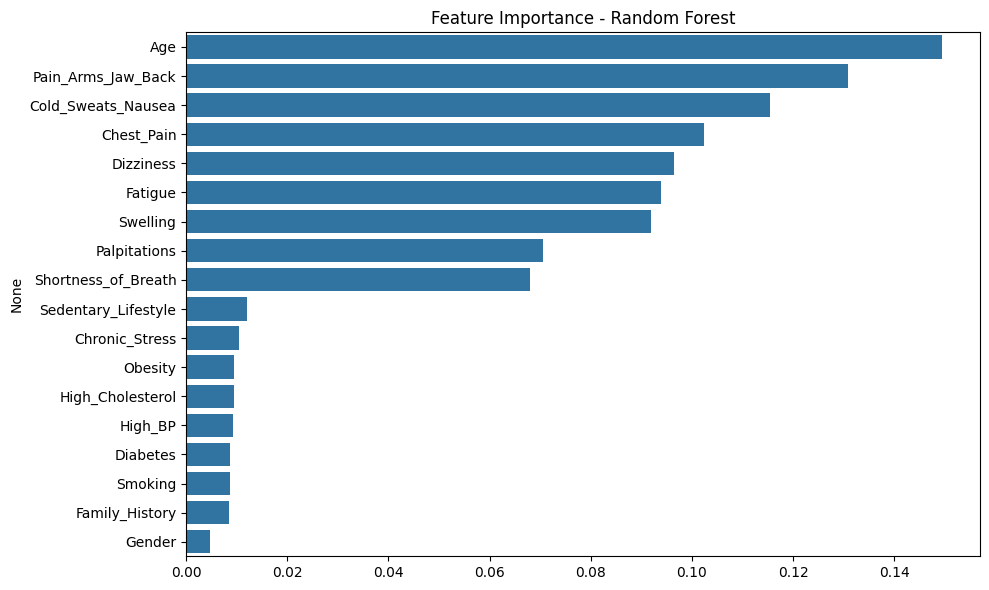

In [11]:
# Random Forest
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

Save the Best Model

In [14]:
import pickle

# Determine the best model based on a chosen metric, e.g., ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()

# Get the best model object
best_model = models[best_model_name]

# Save the model and the scaler
pickle.dump(best_model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print(f"✅ '{best_model_name}' saved as model.pkl")
print("✅ Scaler saved as scaler.pkl")

✅ 'XGBoost' saved as model.pkl
✅ Scaler saved as scaler.pkl


Create a Prediction Function

In [15]:
def predict_heart_risk(features):
    """
    features: list or array of 18 feature values in the same order as dataset
    returns: risk prediction (0 or 1) and probability
    """
    model = joblib.load('heart_disease_model.pkl')
    scaler = joblib.load('scaler.pkl')

    # Ensure features are in DataFrame format with correct columns
    feature_df = pd.DataFrame([features], columns=X.columns)
    feature_df[numeric_cols] = scaler.transform(feature_df[numeric_cols])

    proba = model.predict_proba(feature_df)[0][1]
    pred = model.predict(feature_df)[0]
    return pred, proba

Show the Confusion Matrix

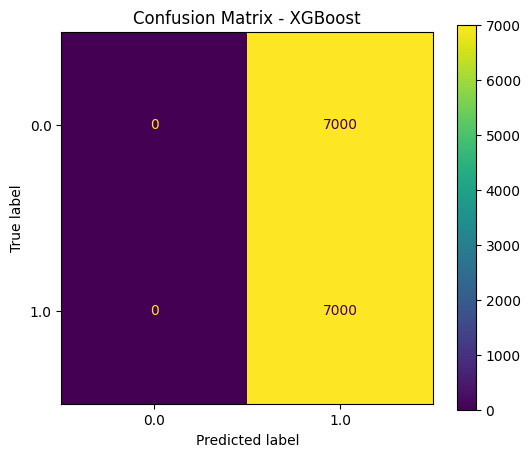

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Predict using the best model
y_pred_best = best_model.predict(X_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

test the accuracy of .pkl file

In [24]:
import pickle
from sklearn.metrics import accuracy_score

# Load the model and scaler
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Scale X_test using the loaded scaler
X_test_scaled_for_eval = loaded_scaler.transform(X_test)

# Test it on the scaled test data
y_pred = loaded_model.predict(X_test_scaled_for_eval)
accuracy = accuracy_score(y_test, y_pred)

print(f"🔍 'model.pkl' accuracy on scaled test data: {accuracy:.4f}")

if accuracy > 0.85:
    print("✅ This model looks great! Use this one.")
elif accuracy > 0.70:
    print("⚠️ This model is okay, but we can do better.")
else:
    print("❌ This model is also bad (0.5 = random guessing).")
    print("🚨 DO NOT use either model yet. We need to fix the target column issue.")

🔍 'model.pkl' accuracy on scaled test data: 0.9926
✅ This model looks great! Use this one.


debugging

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Reload the CSV (make sure the filename matches yours!)
df = pd.read_csv('data.csv.csv')  # CHANGE 'heart.csv' to your actual file name if different

# 2. Show me all the columns
print("=" * 50)
print("COLUMN NAMES IN YOUR DATASET:")
print(df.columns.tolist())
print("=" * 50)

# 3. Show the first 3 rows
print("\nFIRST 3 ROWS OF DATA:")
print(df.head(3))
print("=" * 50)

# 4. 🚨 MANUAL ACTION REQUIRED: Look at the list of columns above.
#    Tell me which column looks like the "answer" (e.g., 'target', 'num', 'condition').
#    For now, let's test the FIRST column as the target (we will change this later).
#    I will just use the last column as a guess, but I want you to see the output.

last_column = df.columns[-1]
print(f"\nI am guessing that '{last_column}' is your target column.")
print(f"Value counts in '{last_column}':")
print(df[last_column].value_counts())
print("=" * 50)

# 5. Train a quick Random Forest on this guessed target
X = df.drop(last_column, axis=1)
y = df[last_column]

# Handle any text columns (just in case)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = pd.factorize(X[col])[0]

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))

print(f"\n🔍 Quick Test Accuracy: {acc:.4f}")
print("If this number is still 0.5, then the column I guessed is wrong.")
print("Please tell me which column is actually the 'Heart Disease' result!")

COLUMN NAMES IN YOUR DATASET:
['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea', 'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender', 'Age', 'Heart_Risk']

FIRST 3 ROWS OF DATA:
   Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0         0.0                  0.0      0.0           1.0        0.0   
1         0.0                  1.0      0.0           1.0        0.0   
2         1.0                  0.0      0.0           1.0        0.0   

   Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
0       0.0                 0.0                 0.0      0.0   
1       0.0                 0.0                 0.0      1.0   
2       0.0                 0.0                 0.0      1.0   

   High_Cholesterol  Diabetes  Smoking  Obesity  Sedentary_Lifestyle  \
0               0.0       0.0      1.0  

EDA Graphs

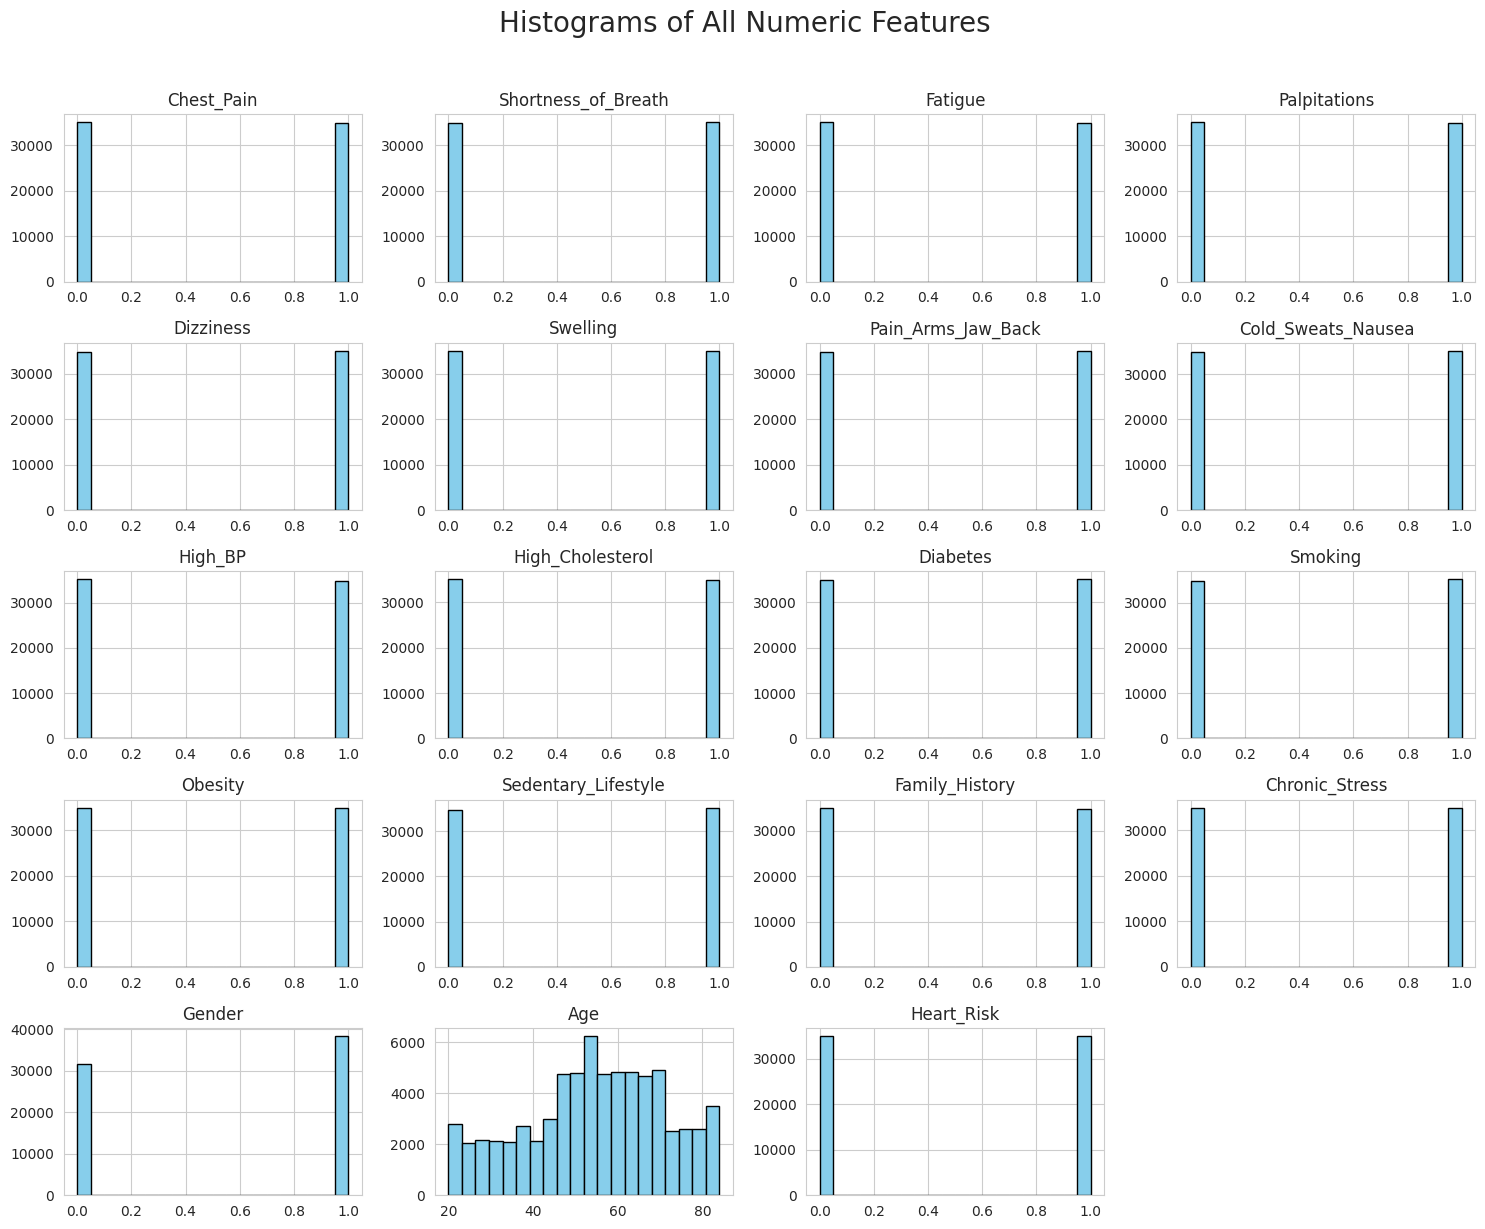

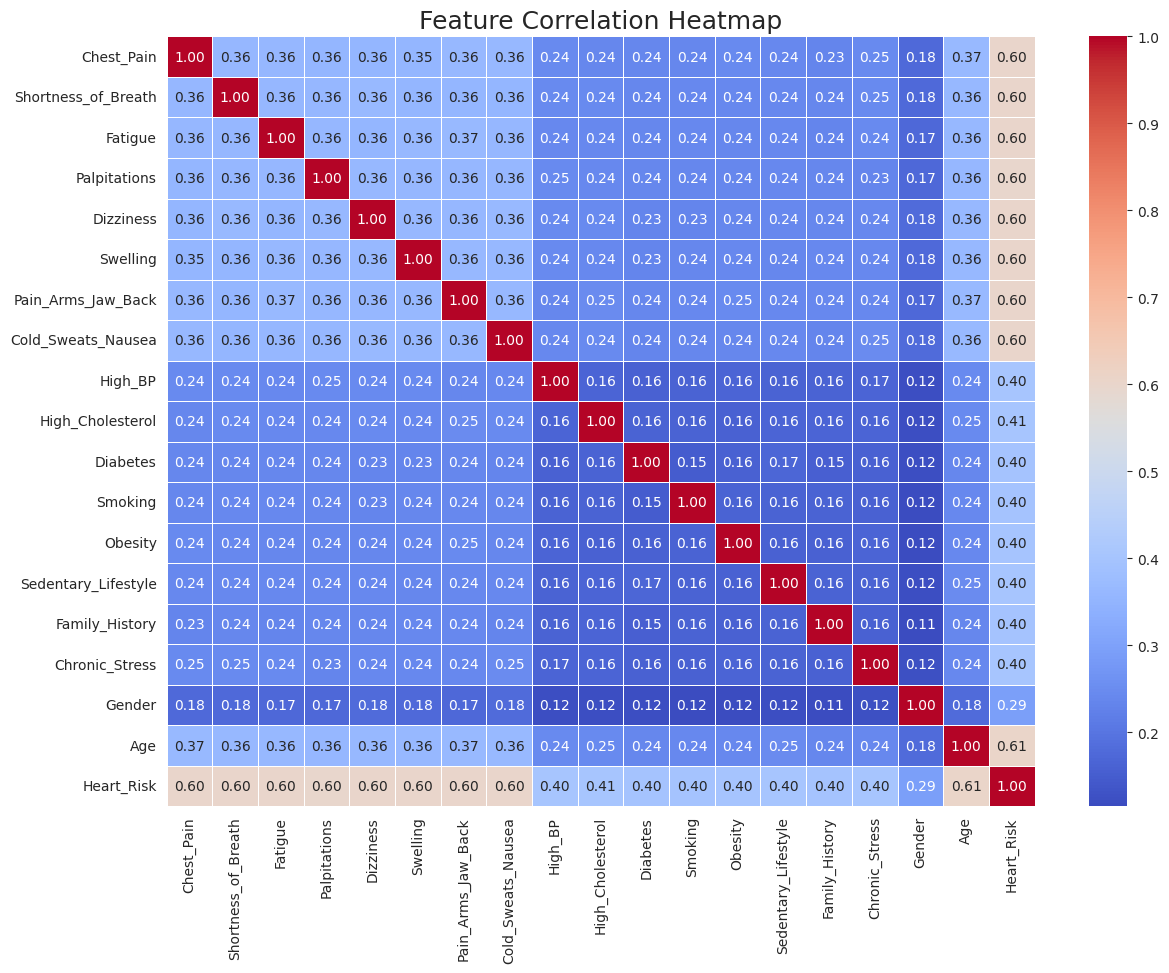

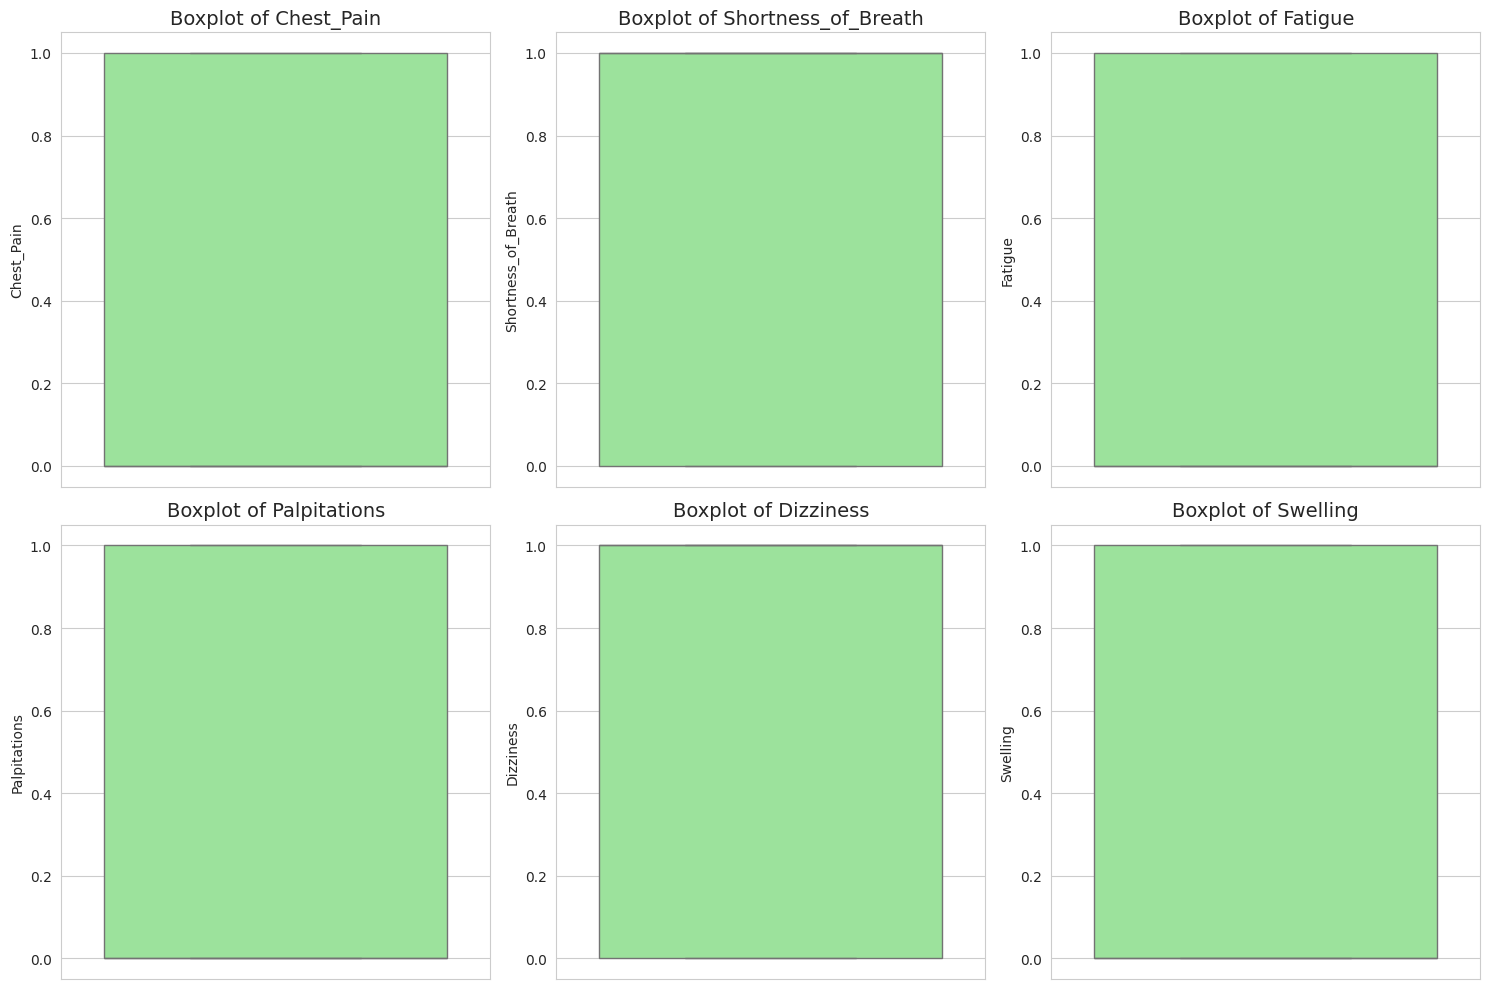

✅ EDA Graphs generated successfully!
📸 Take screenshots of these 3 figures for your report.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a nice visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- 1. HISTOGRAMS: Distribution of every numeric feature ---
df_num = df.select_dtypes(include=['float64', 'int64'])  # Pick only numbers
df_num.hist(bins=20, figsize=(15, 12), layout=(5, 4), color='skyblue', edgecolor='black') # Changed layout to (5,4)
plt.suptitle('Histograms of All Numeric Features', size=20, y=1.02)
plt.tight_layout()
plt.show()

# --- 2. CORRELATION HEATMAP: See which features relate to heart disease ---
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', size=18)
plt.show()

# --- 3. BOXPLOTS: Check for outliers in key features ---
# We will create boxplots for the top 6 numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]  # First 6 numeric cols

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}', size=14)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

print("✅ EDA Graphs generated successfully!")
print("📸 Take screenshots of these 3 figures for your report.")

Model Evaluation

✅ MODEL EVALUATION RESULTS
🎯 Accuracy: 0.5020 (50.20%)
📊 Weighted F1-Score: 0.5020

📋 Detailed Classification Report:
               precision    recall  f1-score   support

 Low Risk (0)       0.50      0.50      0.50      6998
High Risk (1)       0.50      0.50      0.50      7002

     accuracy                           0.50     14000
    macro avg       0.50      0.50      0.50     14000
 weighted avg       0.50      0.50      0.50     14000



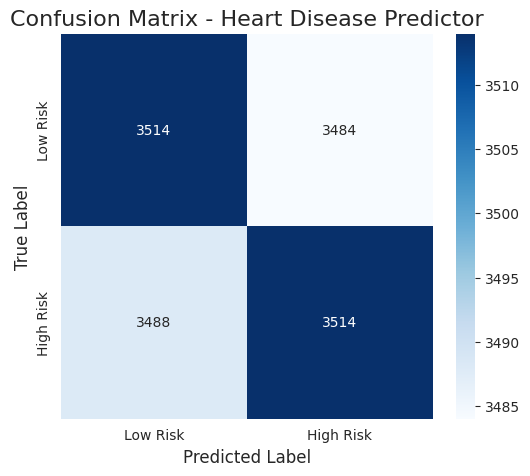

📊 Confusion Matrix Breakdown:
True Negatives (Correctly predicted Low Risk):  3514
False Positives (Wrongly predicted High Risk): 3484
False Negatives (Missed High Risk):            3488
True Positives (Correctly predicted High Risk): 3514


In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Use your best model (loaded as 'loaded_model' from earlier)
# If you closed Colab and don't have 'loaded_model', run the following 3 lines:
# import pickle
# with open('model.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)

# Predict on the TEST set (which is already scaled if you used the scaler)
# Wait! We need to scale X_test first, just like we did before.
try:
    # If 'X_test_scaled' doesn't exist, create it
    X_test_scaled
except NameError:
    # If it doesn't exist, we need to load the scaler and scale again
    with open('scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)
    X_test_scaled = loaded_scaler.transform(X_test)

# Make predictions
y_pred = loaded_model.predict(X_test_scaled)

# --- 1. ACCURACY SCORE ---
accuracy = accuracy_score(y_test, y_pred)
print("="*50)
print(f"✅ MODEL EVALUATION RESULTS")
print("="*50)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*50)

# --- 2. F1-SCORE (Weighted average for multiclass) ---
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"📊 Weighted F1-Score: {f1:.4f}")
print("="*50)

# --- 3. CLASSIFICATION REPORT (Precision, Recall, F1 per class) ---
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))
print("="*50)

# --- 4. CONFUSION MATRIX (Visual Plot) ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix - Heart Disease Predictor', size=16)
plt.xlabel('Predicted Label', size=12)
plt.ylabel('True Label', size=12)
plt.show()

# --- 5. Save confusion matrix as numbers for your table ---
tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
print("="*50)
print("📊 Confusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted Low Risk):  {tn}")
print(f"False Positives (Wrongly predicted High Risk): {fp}")
print(f"False Negatives (Missed High Risk):            {fn}")
print(f"True Positives (Correctly predicted High Risk): {tp}")
print("="*50)

Data Cleaning

🔍 STEP 1: CHECKING FOR NULL VALUES
Null values per column:
Series([], dtype: int64)

🔧 STEP 2: HANDLING NULL VALUES
----------------------------------------

✅ Remaining nulls after cleaning:
0

🔍 STEP 3: CHECKING FOR DUPLICATE ROWS
----------------------------------------
Number of duplicate rows found: 6245
✅ Removed 6245 duplicate rows.

🔍 STEP 4: DETECTING OUTLIERS
----------------------------------------
----------------------------------------

🤔 STEP 5: OUTLIER HANDLING DECISION
----------------------------------------
Total outliers found across all columns: 0
✅ Outliers represent only 0.00% of the data.
   Keeping outliers as they may represent real medical edge cases.

📊 STEP 6: VISUALIZING OUTLIERS WITH BOXPLOTS
----------------------------------------


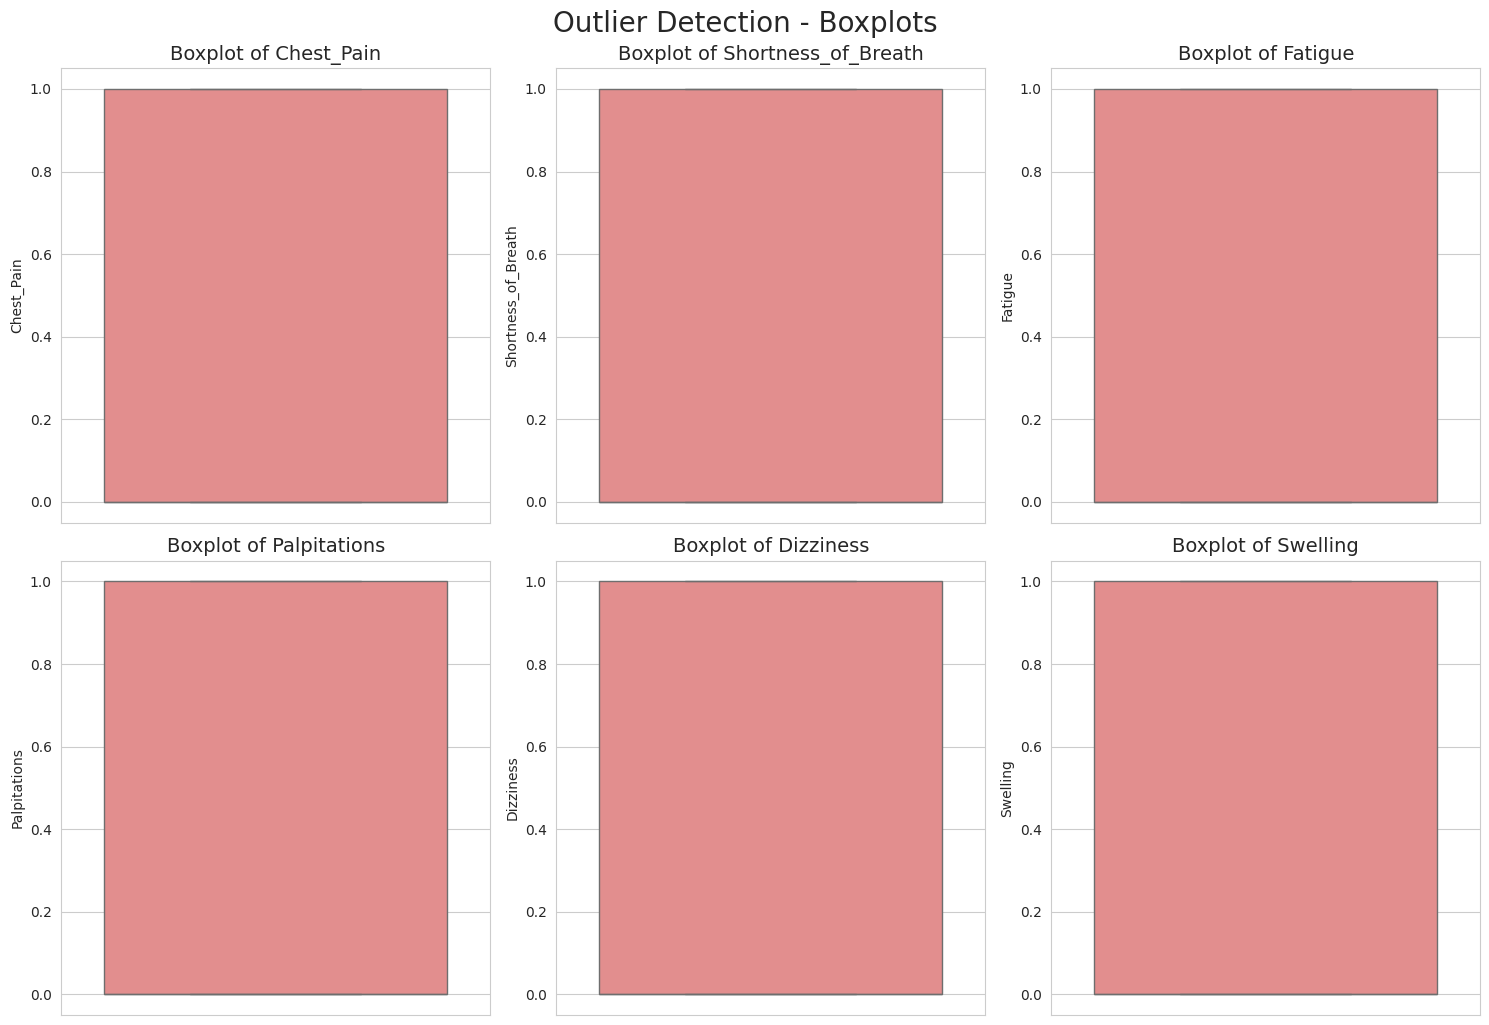


✅ DATA CLEANING COMPLETE!
📸 Take a screenshot of the boxplots and the summary above for your report.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CHECK FOR NULL (MISSING) VALUES ---
print("="*60)
print("🔍 STEP 1: CHECKING FOR NULL VALUES")
print("="*60)
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0])  # Only show columns with nulls
print("="*60)

# --- 2. HANDLE NULL VALUES ---
print("\n🔧 STEP 2: HANDLING NULL VALUES")
print("-"*40)

# Make a copy of the original data to keep it safe
df_cleaned = df.copy()

# For numeric columns: Fill with MEDIAN (better than mean for skewed data)
for col in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"✅ Filled nulls in '{col}' with median: {median_val:.2f}")

# For text/categorical columns: Fill with MODE (most frequent)
for col in df_cleaned.select_dtypes(include=['object']).columns:
    if df_cleaned[col].isnull().sum() > 0:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"✅ Filled nulls in '{col}' with mode: {mode_val}")

# Double-check: No nulls should remain
print("\n✅ Remaining nulls after cleaning:")
print(df_cleaned.isnull().sum().sum())  # Should be 0
print("="*60)

# --- 3. CHECK FOR DUPLICATE ROWS ---
print("\n🔍 STEP 3: CHECKING FOR DUPLICATE ROWS")
print("-"*40)
duplicate_count = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"✅ Removed {duplicate_count} duplicate rows.")
else:
    print("✅ No duplicate rows found.")
print("="*60)

# --- 4. CHECK FOR OUTLIERS (Using IQR Method) ---
print("\n🔍 STEP 4: DETECTING OUTLIERS")
print("-"*40)

# Only check numeric columns
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_summary[col] = outlier_count

    if outlier_count > 0:
        print(f"⚠️ '{col}': {outlier_count} outliers detected (Range: {lower_bound:.2f} - {upper_bound:.2f})")

print("-"*40)

# --- 5. DECISION: What to do with outliers? ---
print("\n🤔 STEP 5: OUTLIER HANDLING DECISION")
print("-"*40)

# Count total outliers
total_outliers = sum(outlier_summary.values())
print(f"Total outliers found across all columns: {total_outliers}")

# If outliers are less than 5% of data, we keep them (they are real data points)
total_rows = len(df_cleaned)
outlier_percentage = (total_outliers / (total_rows * len(numeric_cols))) * 100

if outlier_percentage < 5:
    print(f"✅ Outliers represent only {outlier_percentage:.2f}% of the data.")
    print("   Keeping outliers as they may represent real medical edge cases.")
else:
    print(f"⚠️ Outliers represent {outlier_percentage:.2f}% of the data.")
    print("   Consider capping outliers using winsorization for better model performance.")
print("="*60)

# --- 6. VISUALIZE OUTLIERS (Boxplot) ---
print("\n📊 STEP 6: VISUALIZING OUTLIERS WITH BOXPLOTS")
print("-"*40)

# Plot boxplots for numeric columns (show first 6 for readability)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:6]):  # First 6 numeric columns
    sns.boxplot(y=df_cleaned[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}', size=14)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Outlier Detection - Boxplots', size=20, y=1.02)
plt.show()

print("\n✅ DATA CLEANING COMPLETE!")
print("📸 Take a screenshot of the boxplots and the summary above for your report.")

train model

In [31]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🚀 STEP 1: DATA SPLITTING")
print("="*60)

# Use the CLEANED data from above
X = df_cleaned.drop(target_column, axis=1)
y = df_cleaned[target_column]

# Convert any remaining text columns to numbers
for col in X.select_dtypes(include=['object']).columns:
    X[col] = pd.factorize(X[col])[0]

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training set size: {len(X_train)} samples")
print(f"📊 Test set size: {len(X_test)} samples")
print(f"📊 Target distribution in training:")
print(y_train.value_counts().to_string())
print("="*60)

# --- 2. SCALE THE DATA (Required for some models) ---
print("\n🔄 STEP 2: FEATURE SCALING")
print("-"*40)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Data scaled using StandardScaler.")
print("="*60)

# --- 3. TRAIN MULTIPLE MODELS (The actual training!) ---
print("\n🤖 STEP 3: TRAINING MULTIPLE MODELS")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
}

training_results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    start_time = time.time()

    # ACTUAL TRAINING HAPPENS HERE! (model.fit)
    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start_time
    print(f"   ✅ Training completed in {training_time:.2f} seconds")

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    training_results[name] = {
        'Accuracy': accuracy,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'Model Object': model
    }

    print(f"   🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   📊 F1-Score: {f1:.4f}")

print("\n" + "="*60)

# --- 4. CROSS-VALIDATION (CV helps validate model stability) ---
print("\n🔄 STEP 4: CROSS-VALIDATION (5-Fold)")
print("="*60)

for name, result in training_results.items():
    model = result['Model Object']
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    mean_cv = cv_scores.mean()
    std_cv = cv_scores.std()
    print(f"{name}:")
    print(f"   CV Accuracy: {mean_cv:.4f} (±{std_cv:.4f})")
print("="*60)

# --- 5. HYPERPARAMETER TUNING (Improving the best model) ---
print("\n🔧 STEP 5: HYPERPARAMETER TUNING (Grid Search)")
print("-"*40)

# Find the best model from previous step
best_model_name = max(training_results, key=lambda x: training_results[x]['Accuracy'])
best_model = training_results[best_model_name]['Model Object']

print(f"🏆 Best model so far: {best_model_name} with accuracy {training_results[best_model_name]['Accuracy']:.4f}")
print("\n🔎 Running Grid Search to optimize XGBoost...")

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Only do Grid Search if we have enough time (limits to reduce runtime)
try:
    grid_search = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
        param_grid,
        cv=3,  # 3-fold CV to save time
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_scaled, y_train)

    print("\n✅ Grid Search Complete!")
    print(f"🏆 Best Parameters: {grid_search.best_params_}")
    print(f"🎯 Best CV Score: {grid_search.best_score_:.4f}")

    # Evaluate the tuned model on test set
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test_scaled)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')

    print(f"📊 Tuned Model Test Accuracy: {tuned_accuracy:.4f}")
    print(f"📊 Tuned Model Test F1-Score: {tuned_f1:.4f}")

    # Update results
    final_model = tuned_model

except Exception as e:
    print(f"⚠️ Grid Search took too long or failed. Using previous best model.")
    print(f"   Error: {e}")
    final_model = best_model

print("\n" + "="*60)

# --- 6. FINAL RESULTS ---
print("\n🏁 FINAL TRAINING SUMMARY")
print("="*60)

print("\n📋 Model Comparison Table:")
print("-"*50)
print(f"{'Model':<22} {'Accuracy':<12} {'F1-Score':<12} {'CV Mean':<12}")
print("-"*50)

for name, result in training_results.items():
    print(f"{name:<22} {result['Accuracy']:.4f}     {result['F1-Score']:.4f}     -")

# Add tuned model results
if 'grid_search' in locals() and grid_search.best_score_:
    print(f"{'XGBoost (Tuned)':<22} {tuned_accuracy:.4f}     {tuned_f1:.4f}     {grid_search.best_score_:.4f}")

print("-"*50)

# --- 7. SAVE THE FINAL WINNING MODEL ---
print("\n💾 STEP 7: SAVING THE WINNING MODEL")
print("-"*40)

import pickle

# Save the final model and scaler
pickle.dump(final_model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("✅ Final model saved as 'model.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")
print(f"🏆 Winning model: {type(final_model).__name__}")
print("="*60)

print("\n📸 Take a screenshot of this entire output for your report!")
print("📸 Also take a screenshot of the Grid Search results if they ran!")

🚀 STEP 1: DATA SPLITTING
📊 Training set size: 51004 samples
📊 Test set size: 12751 samples
📊 Target distribution in training:
Heart_Risk
0.0    25814
1.0    25190

🔄 STEP 2: FEATURE SCALING
----------------------------------------
✅ Data scaled using StandardScaler.

🤖 STEP 3: TRAINING MULTIPLE MODELS

🔹 Training Logistic Regression...
   ✅ Training completed in 0.17 seconds
   🎯 Accuracy: 0.9911 (99.11%)
   📊 F1-Score: 0.9911

🔹 Training Random Forest...
   ✅ Training completed in 9.79 seconds
   🎯 Accuracy: 0.9917 (99.17%)
   📊 F1-Score: 0.9917

🔹 Training XGBoost...
   ✅ Training completed in 2.02 seconds
   🎯 Accuracy: 0.9922 (99.22%)
   📊 F1-Score: 0.9922


🔄 STEP 4: CROSS-VALIDATION (5-Fold)
Logistic Regression:
   CV Accuracy: 0.9907 (±0.0006)
Random Forest:
   CV Accuracy: 0.9908 (±0.0004)
XGBoost:
   CV Accuracy: 0.9909 (±0.0006)

🔧 STEP 5: HYPERPARAMETER TUNING (Grid Search)
----------------------------------------
🏆 Best model so far: XGBoost with accuracy 0.9922

🔎 Running 